##Project fashionMnist


In [35]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

###Definition

In [36]:
(X_train,y_train),(X_test,y_test)=keras.datasets.fashion_mnist.load_data()

In [37]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


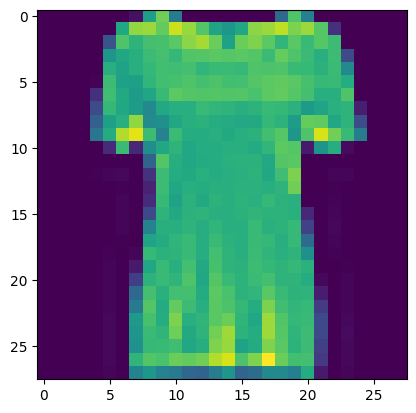

In [38]:
plt.imshow(X_train[10])

###Normalization

In [39]:
X_train, X_test = X_train/255, X_test/255

In [40]:
len(np.unique(y_train))

10

###Model

In [41]:
model = keras.models.Sequential(
    [
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(10,activation="softmax"),
    ]
 )

In [42]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

###compile

In [43]:
model.compile(
        optimizer="adam",
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
)

###EarlyStopping

In [44]:
eary_stop=EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

###fit

In [45]:
history=model.fit(
        X_train,
        y_train,
        epochs =30,
        batch_size =32,
        validation_data =(X_test,y_test),
        callbacks =[eary_stop]
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8210 - loss: 0.5015 - val_accuracy: 0.8355 - val_loss: 0.4375
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8651 - loss: 0.3671 - val_accuracy: 0.8637 - val_loss: 0.3802
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8786 - loss: 0.3309 - val_accuracy: 0.8723 - val_loss: 0.3509
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8858 - loss: 0.3100 - val_accuracy: 0.8673 - val_loss: 0.3696
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8913 - loss: 0.2930 - val_accuracy: 0.8791 - val_loss: 0.3308
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8951 - loss: 0.2794 - val_accuracy: 0.8764 - val_loss: 0.3561
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8996 - loss: 0.2677 - val_accuracy: 0.8775 - val_loss: 0.3404
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9030 - loss: 0.2566 

###trainingPerformance

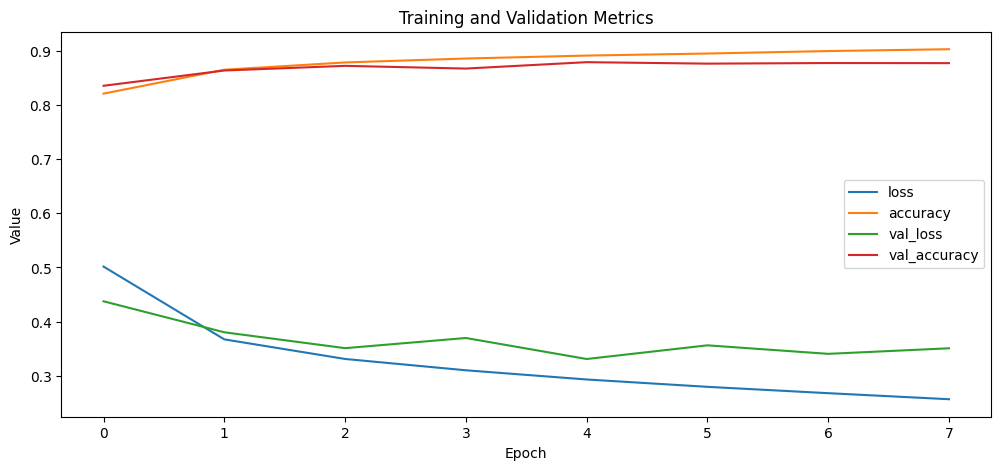

In [46]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['accuracy'], label='accuracy')
ax.plot(history.history['val_loss'], label='val_loss')
ax.plot(history.history['val_accuracy'], label='val_accuracy')

ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_title('Training and Validation Metrics')
ax.legend()
plt.show()

### testModel

In [47]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [48]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8791 - loss: 0.3308


[0.33084356784820557, 0.8791000247001648]

In [49]:
pred = model.predict(X_test[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [50]:
np.argmax(pred, axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 2, 8, 0])

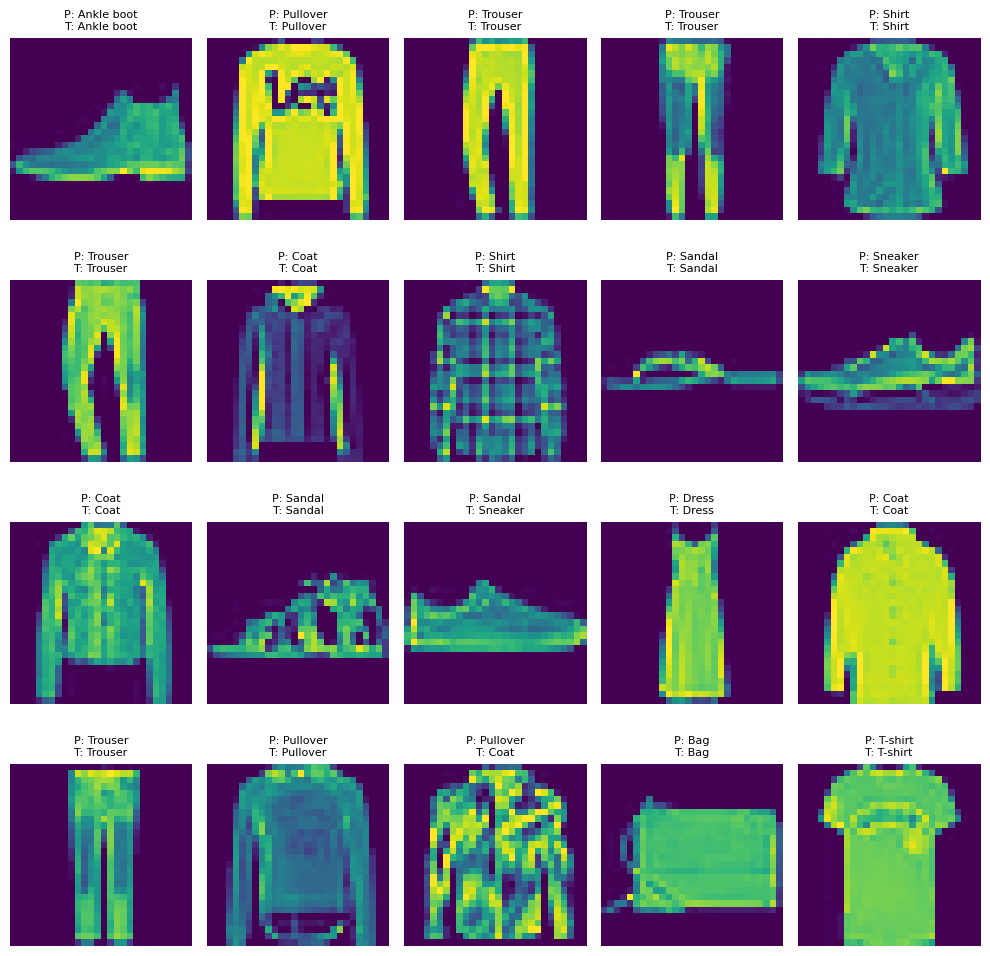

In [51]:

plt.figure(figsize=(10, 10))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i])
    plt.title(
        f"P: {class_names[np.argmax(pred[i])]}\n"
        f"T: {class_names[y_test[i]]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()